이상 데이터 추출

In [ ]:
import pandas as pd
import numpy as np

In [3]:
df1 = pd.read_csv('test_features.csv')
df2 = pd.read_csv('train_features.csv')
df3 = pd.read_csv('valid_features.csv')
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_csv('combined_features.csv', index=False, encoding="utf-8-sig")

In [5]:
#이상치에 사용될 feature들
feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X = df[feature_cols].copy()

print(X.shape)
X.head()

(49738, 8)


,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
0,-0.068409,0.510212,-0.000600,0.018517,0.008333,0.333333,0.266667,2.0
1,0.073703,0.555255,-0.007203,0.015540,0.015476,0.000000,0.685714,2.0
2,0.116779,0.642674,0.011487,0.016489,0.002980,0.024390,0.536585,1.0
3,-0.370103,0.420625,-0.015541,0.015359,0.018474,0.657143,0.114286,1.0
4,2.306016,1.392989,0.015179,0.012786,0.021650,0.536232,0.449275,2.0


In [6]:
# 1. inf 값을 NaN으로 바꾸기
df = df.replace([np.inf, -np.inf], np.nan)

# 2. feature 컬럼 기준 결측치 제거
df = df.dropna(subset=feature_cols).copy()

# 3. 너무 큰 값 잘라내기: 극단값 완화
for col in feature_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

# 4. 다시 X 생성
X = df[feature_cols].copy()

print(X.isna().sum())
print(np.isinf(X).sum())
print(X.shape)

vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
(49731, 8)


In [8]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
iso_model.fit(X)

#이상치 점수
df["anomaly_score"] = -iso_model.decision_function(X)
#label명 바꾸기 (정상:1, 이상치:-1) => (정상:0, 이상치:1)
df["anomaly_label"] = iso_model.predict(X)
df["anomaly_label"] = df["anomaly_label"].map({1: 0, -1: 1})

#정상 데이터와 이상 데이터 개수 표시
df["anomaly_label"].value_counts()

anomaly_label
0    48239
1     1492
Name: count, dtype: int64

In [13]:
df[[
    "date",
    "ticker",
    "anomaly_score",
    "anomaly_label"
]].head()

,date,ticker,anomaly_score,anomaly_label
0,2026-03-25,000080.KS,-0.223506,0
1,2026-03-26,000080.KS,-0.218555,0
2,2026-03-27,000080.KS,-0.222545,0
3,2026-03-30,000080.KS,-0.185070,0
4,2026-03-31,000080.KS,-0.142393,0


In [14]:
#이상치 점수가 가장 높은 30개의 데이터 확인
top_anomaly = (
    df
    .sort_values("anomaly_score", ascending=False)
    .head(30)
)

top_anomaly[[
    "date",
    "ticker",
    "anomaly_score",
    "vol_chg_rate",
    "volume_ma20_ratio",
    "volatility_5d",
    "upper_shadow_ratio"
]]

,date,ticker,anomaly_score,vol_chg_rate,volume_ma20_ratio,volatility_5d,upper_shadow_ratio
22076,2024-09-25,021040.KQ,0.143688,5.012911,5.071772,0.105396,0.866667
22220,2025-04-30,021040.KQ,0.138924,5.840757,5.071772,0.105396,0.841584
37797,2025-09-12,060230.KQ,0.134109,5.840757,5.071772,0.085276,0.809417
37249,2025-03-21,058450.KQ,0.132565,5.840757,5.071772,0.105396,0.000000
41420,2025-09-01,083660.KQ,0.131305,5.840757,5.071772,0.105396,0.011390
37667,2025-03-06,060230.KQ,0.131130,5.840757,5.071772,0.105396,0.034783
2195,2026-05-20,035620.KQ,0.129797,4.818551,5.071772,0.105396,0.038462
41414,2025-08-22,083660.KQ,0.128358,5.840757,5.071772,0.105396,0.233859
24392,2024-11-15,025950.KQ,0.128271,5.443709,5.071772,0.105396,0.343189
37543,2024-07-16,060230.KQ,0.127148,5.840757,5.071772,0.105396,0.538922


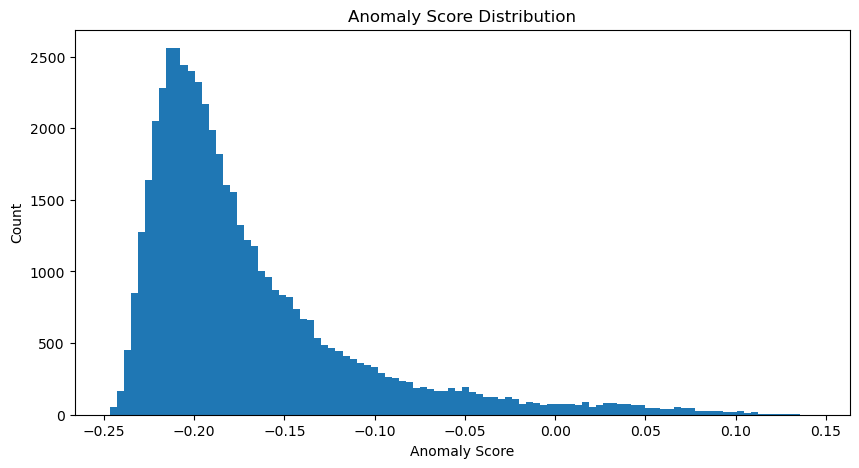

In [15]:
#이상치 점수 분포 확인
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["anomaly_score"], bins=100)

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")

plt.show()

이상 데이터 분리 후 클러스터링

In [16]:
#이상 데이터만 따로 분류
anomaly_df = df[
    df["anomaly_label"] == 1
].copy()

In [17]:
#클러스터링에 사용할 feature들

cluster_feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X_cluster = anomaly_df[cluster_feature_cols].copy()

#클러스터링 전 전처리: 무한대 값 및 결측치 포함된 행 제거
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.dropna()

# anomaly_df도 X_cluster 인덱스에 맞추기
anomaly_df = anomaly_df.loc[X_cluster.index].copy()

print(X_cluster.shape)

(1492, 8)


In [18]:
#클러스터링 전 스케일링
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\asdf\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\asdf\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(a

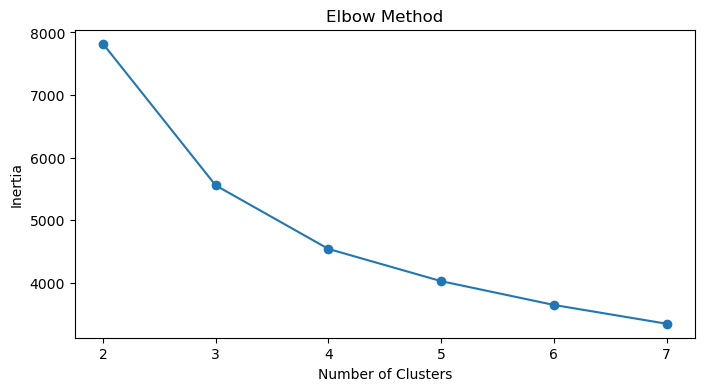

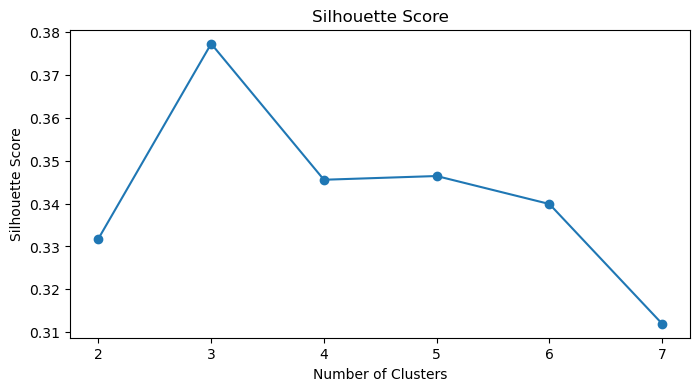

,k,inertia,silhouette
0,2,7819.376204,0.331834
1,3,5555.504108,0.377278
2,4,4540.193218,0.345557
3,5,4025.194327,0.346426
4,6,3645.007905,0.339904
5,7,3344.856548,0.311985


In [19]:
#K-Means 수행 전 K 설정 위한 inertia, silhouette score 확인
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

In [20]:
#k=3 에서 높은 실루엣 점수가 나타났으니 k=3으로 설정 후 K-Means 진행

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
anomaly_df["cluster"] = kmeans.fit_predict(X_cluster_scaled)

anomaly_df["cluster"].value_counts().sort_index()

C:\asdf\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


cluster
0    766
1    319
2    407
Name: count, dtype: int64

In [21]:
#클러스터 별 feature 평균값 확인
cluster_profile = (
    anomaly_df
    .groupby("cluster")[cluster_feature_cols]
    .mean()
)

cluster_profile

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.446276,4.362441,0.065924,0.055836,0.054536,0.330273,0.621091,1.539164
1,0.161143,1.059942,0.000047,0.000596,0.233310,0.485558,4.724505,2.868339
2,0.754000,2.295577,-0.040404,0.088324,0.197231,0.248190,0.605371,1.471744


In [22]:
#평균값 표준화 시킨 후 재확인
cluster_profile_scaled = pd.DataFrame(
    cluster_scaler.transform(cluster_profile),
    columns=cluster_feature_cols,
    index=cluster_profile.index
)

cluster_profile_scaled

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.738758,0.705708,0.699213,0.073637,-0.842524,-0.037867,-0.494333,-0.215096
1,-0.907116,-1.129535,-0.369753,-1.306134,1.109831,0.506106,1.829078,0.860543
2,-0.679406,-0.442876,-1.026157,0.885136,0.715816,-0.325410,-0.503235,-0.269656


In [23]:
#클러스터별 주요 특징
for cluster_id in sorted(anomaly_df["cluster"].unique()):
    print(f"\n===== Cluster {cluster_id} 주요 특징 =====")

    row = cluster_profile_scaled.loc[cluster_id].sort_values(ascending=False)
    print(row.head(5))


===== Cluster 0 주요 특징 =====
vol_chg_rate          0.738758
volume_ma20_ratio     0.705708
daily_return          0.699213
volatility_5d         0.073637
upper_shadow_ratio   -0.037867
Name: 0, dtype: float64

===== Cluster 1 주요 특징 =====
body_ratio                1.829078
drawdown_after_peak_5d    1.109831
upper_shadow_streak_5d    0.860543
upper_shadow_ratio        0.506106
daily_return             -0.369753
Name: 1, dtype: float64

===== Cluster 2 주요 특징 =====
volatility_5d             0.885136
drawdown_after_peak_5d    0.715816
upper_shadow_streak_5d   -0.269656
upper_shadow_ratio       -0.325410
volume_ma20_ratio        -0.442876
Name: 2, dtype: float64


In [24]:
anomaly_df.to_csv("anomaly_cluster_result.csv", index=False, encoding="utf-8-sig")
cluster_profile.to_csv("cluster_profile_raw.csv", encoding="utf-8-sig")
cluster_profile_scaled.to_csv("cluster_profile_scaled.csv", encoding="utf-8-sig")